<a href="https://colab.research.google.com/github/anamikasarker21/AI-ML/blob/main/MNIST_ANN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
import os
import cv2

In [ ]:
#load data
Train_data_path= '/content/drive/MyDrive/Digit_Detection/TrainingSet'
Test_data_path= "/content/drive/MyDrive/Digit_Detection/TestSet"

train_data=[]
train_label=[]
test_data=[]
test_label=[]


for label in range(10):
    # Load train
    folder = os.path.join(Train_data_path, str(label))
    for file in os.listdir(folder):
        img = cv2.imread(os.path.join(folder, file), cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, (28, 28))
        train_data.append(img)
        train_label.append(label)

    # Load test
    folder = os.path.join(Test_data_path, str(label))
    for file in os.listdir(folder):
        img = cv2.imread(os.path.join(folder, file), cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, (28, 28))
        test_data .append(img)
        test_label .append(label)
train_data= np.array(train_data)
train_label= np.array(train_label)
test_data= np.array(test_data)
test_label=np.array(test_label)


In [ ]:
train_data.shape
train_label.shape

(33617,)

In [ ]:
perm = np.random.permutation(len(train_data))
train_data = train_data[perm]
train_label = train_label[perm]

In [ ]:
train_data = train_data[:int(len(train_data) * 0.8)]
train_label = train_label[:int(len(train_label) * 0.8)]
valid_data= train_data[int(len(train_data) * 0.8):]
valid_label= train_label[int(len(train_label) * 0.8):]

In [ ]:
valid_data.shape

(5379, 28, 28)

In [ ]:

#normalise data
train_data = train_data / 255
valid_data= valid_data/255
test_data= test_data/255

In [ ]:
#flatten
train_data=train_data.reshape(-1,784)
valid_data= valid_data.reshape(-1, 784)
test_data= test_data.reshape(8396, 784)

In [ ]:
train_data.shape
valid_data.shape

(5379, 784)

In [ ]:
test_data.shape

(8396, 784)

In [ ]:
train_label.shape

(26893,)

In [ ]:
import numpy as np
from keras.models import Sequential
from keras.layers import Dense, Dropout, BatchNormalization
from keras.utils import to_categorical
from keras import backend as K

# fix random seed for reproducibility
seed = 7
np.random.seed(seed)

In [ ]:
# Define a function to create a model
def create_model():
    # create model
    model = Sequential()
    model.add(Dense(256, activation='relu', input_shape=(784, )))
    model.add(BatchNormalization())
    model.add(Dropout(.2))
    model.add(Dense(128, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(.2))
    model.add(Dense(10, activation='softmax'))
    # Compile model
    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

In [ ]:
model = create_model()
print(model.summary())

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 236,682 (924.54 KB)

 Trainable params: 235,914 (921.54 KB)

 Non-trainable params: 768 (3.00 KB)

None


In [ ]:


# build the model
model = create_model()
epochs=25

# Convert labels to one-hot encoding
from keras.utils import to_categorical
train_label_one_hot = to_categorical(train_label, num_classes=10)
valid_label_one_hot = to_categorical(valid_label, num_classes=10)

# Fit the model and store the history
history = model.fit(train_data, train_label_one_hot, epochs=epochs, batch_size=200, verbose=1, validation_data=(valid_data, valid_label_one_hot))

Epoch 1/25
135/135 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.8693 - loss: 0.4291 - val_accuracy: 0.9292 - val_loss: 0.4363
Epoch 2/25
135/135 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.9466 - loss: 0.1803 - val_accuracy: 0.9684 - val_loss: 0.1487
Epoch 3/25
135/135 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9611 - loss: 0.1252 - val_accuracy: 0.9756 - val_loss: 0.0838
Epoch 4/25
135/135 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9698 - loss: 0.0994 - val_accuracy: 0.9842 - val_loss: 0.0550
Epoch 5/25
135/135 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9750 - loss: 0.0804 - val_accuracy: 0.9887 - val_loss: 0.0393
Epoch 6/25
135/135 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9797 - loss: 0.0639 - val_accuracy: 0.9914 - val_loss: 0.0312
Epoch 7/25
135/135 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.9819 - loss: 0.0559 - val_accuracy: 0.9948 - val_loss: 0.0195
Epoch 8/25
135/135 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.9840 - loss: 0.0493 - val_accu

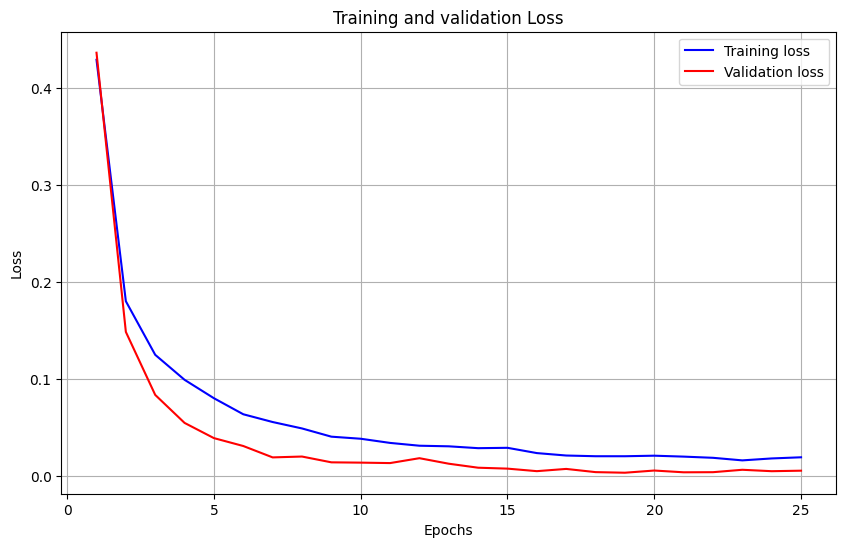

In [ ]:
import matplotlib.pyplot as plt

# Get training loss from history
train_loss = history.history['loss']
valid_loss=history.history['val_loss']
# Get number of epochs
epochs = range(1, len(train_loss) + 1)


# Plot both losses
plt.figure(figsize=(10, 6))
plt.plot(epochs, train_loss, 'b', label='Training loss')
plt.plot(epochs, valid_loss, 'r', label='Validation loss')
plt.title('Training and validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# It's crucial to ensure 'test_label' is a 1D array of integers here before this conversion.
# If you've run this cell multiple times or 'test_label' was already modified, you might need to re-run
# the data loading cell (XrOZ2zAVlHBo) and subsequent preprocessing cells to reset 'test_label'.

from keras.utils import to_categorical
test_label_one_hot = to_categorical(test_label, num_classes=10)
test_label_one_hot.shape

(8396, 10)

In [ ]:
# Evaluate the model on the test data
scores = model.evaluate(test_data, test_label_one_hot, verbose=0)
print("Accuracy on test data: %.2f%%" % (scores[1]*100))
print("Test loss: %.2f" % (scores[0]))

Accuracy on test data: 97.70%
Test loss: 0.10


In [ ]:
y_pred = np.argmax(model.predict(test_data), axis=1)


263/263 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step


In [ ]:

from sklearn.metrics import  confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
accuracy  = accuracy_score(test_label, y_pred)
precision = precision_score(test_label, y_pred, average='weighted')
recall    = recall_score(test_label, y_pred, average='weighted')
f1        = f1_score(test_label, y_pred, average='weighted')

print(f"Accuracy  : {accuracy  * 100:.2f}%")
print(f"Precision : {precision * 100:.2f}%")
print(f"Recall    : {recall    * 100:.2f}%")
print(f"F1 Score  : {f1        * 100:.2f}%")



Accuracy  : 97.70%
Precision : 97.71%
Recall    : 97.70%
F1 Score  : 97.70%


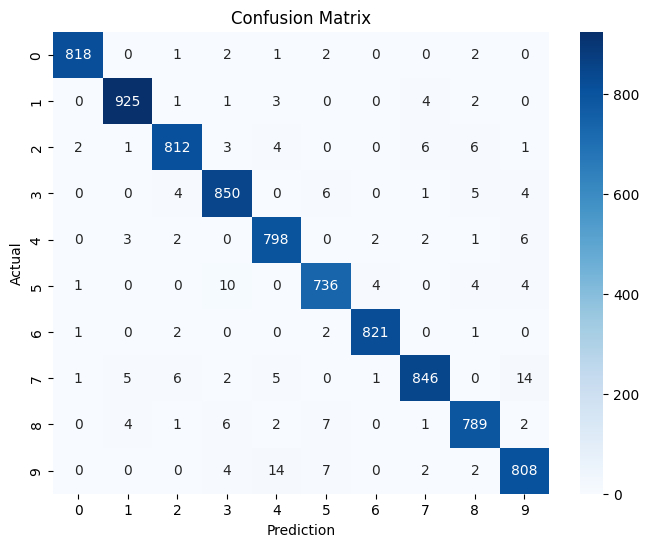

In [ ]:
y_true = test_label
confusionmatrics = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(
    confusionmatrics,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=range(10),
    yticklabels=range(10)
)

plt.xlabel("Prediction")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()